# Project: Job Recommendation System
## Job Recommendation System - Pakistan Job Market (Dec 2019 - Mar 2021)

### Problem Statement
Pakistan's job market has thousands of listings across diverse industries.
This project analyzes job posting trends and builds a recommendation system 
that matches candidates to suitable jobs based on their profile and experience.

### 1. Data Understanding & Acquisition Objectives
- Understand the Pakistan job market landscape
- Identify in-demand roles, cities, and experience levels
- Build a data-driven job recommendation system

# **Step-1 Data Understanding & Acquisition**
### Loading the dataset and inspecting its structure, types, and quality.

In [58]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
df = pd.read_csv('files/Pakistan Available Job Dec 19 - Mar-21.csv')
df.head(5)

,Job Name,label,Company Name,Job Type,Experience Required,Department,JD,City,Date Posted
0,"Full Time New Job Positions .Net, .Netcore, Fl...",Premium Job,"Nayel Solutions, Pakistan",Full Time Jobs,2 Years Job Exp.,IT Jobs,"New Job Positions .net, .netcore, flutter, Tea...",Islamabad,12-Mar-21
1,Full Time Senior Web Developer Jobs in Pakistan,Premium Job,"Eurosoft Tech Private Limited, Pakistan",Full Time Jobs,2 Years Job Exp.,IT Jobs,We are looking for an experienced Web Develope...,Karachi,12-Mar-21
2,Full Time Russian Speakers Jobs in Pakistan,Premium Job,"ICM JAPAN, Pakistan",Full Time Jobs,< 1 Year,Customer Service Jobs,International clients dealing exposure (B2B).S...,Karachi,12-Mar-21
3,Full Time Customer Support Specialist - Intern...,Premium Job,"ibex, Pakistan",Full Time Jobs,Job for Fresh Graduates,Customer Service Jobs,Responsible for acting as a liaison between ou...,Islamabad,9-Mar-21
4,Full Time English Speaker - International Busi...,Premium Job,"ICM JAPAN, Pakistan",Full Time Job,< 1 Year,Customer Service Job,International clients dealing exposure (B2B) a...,Karachi,5-Mar-21


In [60]:
# We check for nulls, types, and initial structure to understand data quality
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6680 entries, 0 to 6679
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Job Name             6680 non-null   object
 1   label                1115 non-null   object
 2   Company Name         6017 non-null   object
 3   Job Type             6680 non-null   object
 4   Experience Required  6680 non-null   object
 5   Department           6680 non-null   object
 6   JD                   6680 non-null   object
 7   City                 6680 non-null   object
 8   Date Posted          6680 non-null   object
dtypes: object(9)
memory usage: 469.8+ KB


In [61]:
# This tells us how jobs are promoted (Gallery, Hot, Premium)
# Important: 83% of labels are missing, so this column may only be useful for insights, not modeling
df.label.value_counts()

label
Gallery Job    775
Hot Job        217
Premium Job    123
Name: count, dtype: int64

In [62]:
df.describe()

,Job Name,label,Company Name,Job Type,Experience Required,Department,JD,City,Date Posted
count,6680,1115,6017,6680,6680,6680,6680,6680,6680
unique,3838,3,2879,2,17,111,5043,86,443
top,Full Time Graphic Designer Job in Pakistan,Gallery Job,"ibex, Pakistan",Full Time Job,2 Years Job Exp.,IT Job,To generate quality leads that result in sales...,Lahore,23-Feb-21
freq,60,775,93,3821,1635,820,37,2046,134


In [63]:
df.duplicated().value_counts()

False    5625
True     1055
Name: count, dtype: int64

# Step 2: Data Preparation & Cleaning
### Fixing inconsistencies, removing duplicates, normalizing columns, and converting data types for analysis.

### 2.1 Drop Irrelevant Columns
The `label` column (Gallery/Hot/Premium) is 83% null — not useful for modeling.

In [64]:
try:
    df.drop(['label'],axis=1,inplace=True)
    print('Label column is being dropped')
except:
    print('Label column already dropped')

Label column is being dropped


### 2.2 Fix Job Type & Extract from Job Name
 All job names start with "Full Time" or "Online Full Time" — 
 this is actually the job type embedded in the name. We extract it 
 into its own column and clean the job name.


In [65]:
# Extract job type from job name prefix
df['Job Type'] = [
    'Online Full Time' if ' '.join(v.split()[:2]) == 'Online Full'
    else 'Full Time'
    for v in df['Job Name']
]

# Remove the prefix from job name
def remove_job_key(name):
    words = name.split()
    first_two = " ".join(words[:2])
    if first_two == "Online Full" and len(words) > 2 and words[2].lower() == "time":
        return " ".join(words[3:])
    else:
        return " ".join(words[2:])

df['Job Name'] = df['Job Name'].apply(remove_job_key)

print(df['Job Type'].value_counts())

Job Type
Full Time           6070
Online Full Time     610
Name: count, dtype: int64


### 2.3 Parse Date & Set as Index

In [66]:
df['Date Posted'] = pd.to_datetime(df['Date Posted'], dayfirst=True)
df.set_index('Date Posted', inplace=True)
df.rename(columns={'JD': 'Job Description'}, inplace=True)
df = df.sort_index()
print(f"Date range: {df.index.min()} → {df.index.max()}")

/tmp/ipykernel_18404/4223110632.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Posted'] = pd.to_datetime(df['Date Posted'], dayfirst=True)


Date range: 2019-12-18 00:00:00 → 2021-03-15 00:00:00


### 2.4 Remove Duplicates
Normalize text temporarily to catch case/spacing duplicates, 
then drop from original dataframe to preserve formatting.

In [67]:
text_cols = df.select_dtypes(include='object').columns
df_temp = df.copy()
for col in text_cols:
    df_temp[col] = df_temp[col].str.lower().str.strip().str.replace(r'\s+', ' ', regex=True)

dupes_mask = df_temp.duplicated(keep='last')
df = df[~dupes_mask]
print(f"Rows after deduplication: {df.shape[0]}")

Rows after deduplication: 5298


### 2.5 Normalize Department & Job Name Columns
Standardize "Job" vs "Jobs" inconsistency across Department and Job Name.

In [68]:
df['Department'] = df['Department'].str.replace(r'\bJobs?\b', 'Jobs', regex=True)
df['Job Name']   = df['Job Name'].str.replace(r'\bJobs?\b', 'Jobs', regex=True)
print(df['Department'].value_counts().head(10))

Department
IT Jobs                   1187
Computer Software Jobs     715
Web & E-commerce Jobs      484
Customer Service Jobs      369
Sales Jobs                 353
Marketing Jobs             343
Admin Jobs                 188
Engineering Jobs           169
Education Jobs             110
Real Estate Jobs            94
Name: count, dtype: int64


### 2.6 Fix Company Name Nulls

In [69]:
df['Company Name'] = df['Company Name'].fillna('Unknown')
print(df['Company Name'].isna().sum(), 'nulls remaining')

0 nulls remaining


### 2.7 Clean Experience from Job Names
Some job names contain experience requirements embedded in the title — 
we remove these as they belong in the Experience Required column.

In [70]:
# Remove parenthetical experience notes e.g. "(3-4 years experience)"
df['Job Name'] = df['Job Name'].str.replace(r'\s*\(.*?experience.*?\)', '', 
                                             case=False, regex=True).str.strip()
# Remove leading "Experienced"
df['Job Name'] = df['Job Name'].str.replace(r'^Experienced\s+', '', case=False, regex=True)
# Remove trailing "Experience/Experienced"
df['Job Name'] = df['Job Name'].str.replace(r'\s+Experienced?$', '', case=False, regex=True)
# Remove "X Year(s) Experience" pattern
df['Job Name'] = df['Job Name'].str.replace(r'\d+[-\d]*\s+Years?\s+Experience\s*', '', 
                                             case=False, regex=True)

# Verify remaining - only legitimate titles should contain "experience"
mask = df['Job Name'].str.contains('experience', case=False, na=False)
print(f"{mask.sum()} job names still contain 'experience'")

25 job names still contain 'experience'


### 2.8 Convert Experience Required to Numeric
Map experience strings to numeric values for analysis and modeling.
- "Job for Fresh Graduates" / "Job for Students" → 0
- "< 1 Year" → 0.5  
- "X Years Job Exp." → X

In [71]:
import re
def parse_experience(val):
    if 'fresh' in val.lower() or 'student' in val.lower():
        return 0
    elif '< 1' in val:
        return 0.5
    else:
        match = re.search(r'(\d+)', val)
        if match:
            return int(match.group(1))
    return None

df['Experience Required'] = df['Experience Required'].apply(parse_experience)
print(df['Experience Required'].value_counts().sort_index())
print(f"\nNulls: {df['Experience Required'].isna().sum()}")

Experience Required
0.0      451
0.5     1289
1.0     1077
2.0     1262
3.0      659
4.0      179
5.0      268
6.0       27
7.0       17
8.0       25
9.0        2
10.0      32
12.0       2
14.0       1
15.0       6
25.0       1
Name: count, dtype: int64

Nulls: 0


### 2.9 Fix Corrupted Job Descriptions
Some descriptions contain "#NAME?" — an Excel formula error from scraping. 
These rows have no usable description and are dropped.

In [72]:
df['Job Description'] = df['Job Description'].replace('#NAME?', np.nan)
print(f"Corrupted descriptions: {df['Job Description'].isna().sum()}")
df.dropna(subset=['Job Description'], inplace=True)
print(f"Final dataset shape: {df.shape}")

Corrupted descriptions: 12
Final dataset shape: (5286, 7)


### 2.10 Cleaning Summary

In [73]:
print("=== FINAL DATASET SUMMARY ===")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nNull values:\n{df.isna().sum()}")

=== FINAL DATASET SUMMARY ===
Rows: 5286
Columns: 7
Date range: 2019-12-18 → 2021-03-15

Column types:
Job Name                object
Company Name            object
Job Type                object
Experience Required    float64
Department              object
Job Description         object
City                    object
dtype: object

Null values:
Job Name               0
Company Name           0
Job Type               0
Experience Required    0
Department             0
Job Description        0
City                   0
dtype: int64


## Step 3: Exploratory Data Analysis
Visualizing the cleaned dataset to uncover patterns in job postings,
departments, cities, and experience requirements.

### 3.1 Top 15 Departments by Job Postings

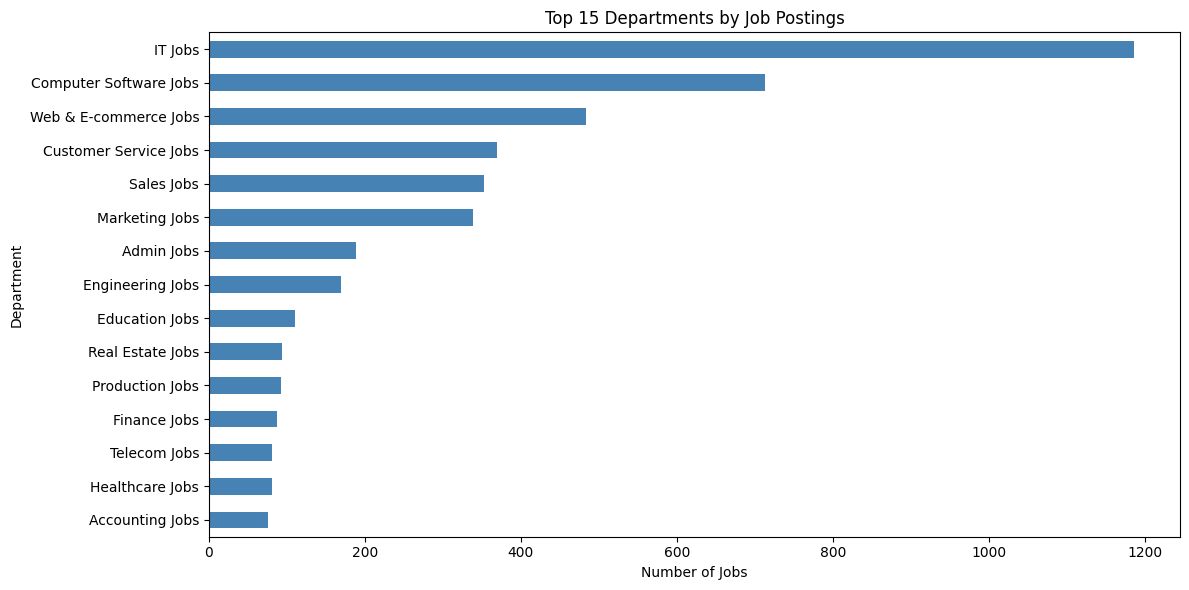

In [74]:
plt.figure(figsize=(12,6))
df['Department'].value_counts().head(15).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Departments by Job Postings')
plt.xlabel('Number of Jobs')
plt.tight_layout()
plt.show()

> **Insight:** IT Jobs dominate the market, followed by Computer Software and 
Web & E-commerce — reflecting Pakistan's growing tech industry.

### 3.2 Experience Distribution

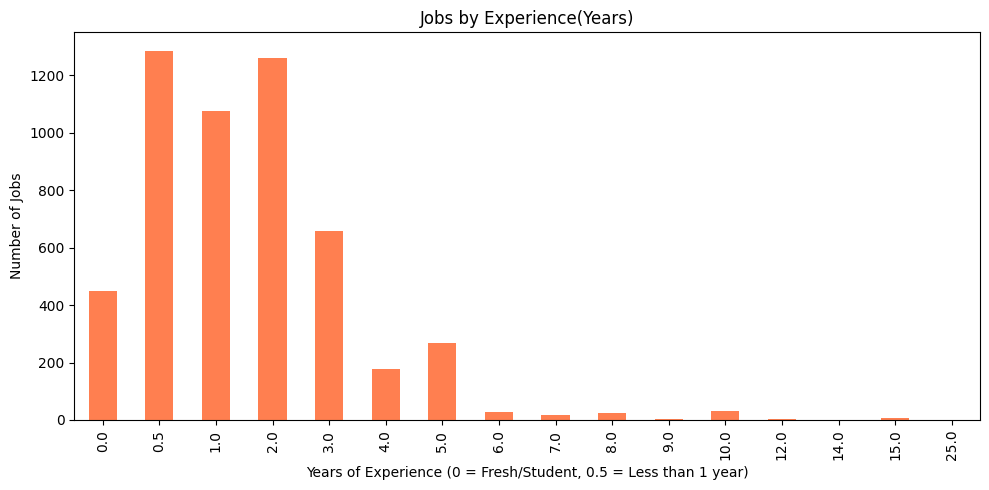

In [75]:
plt.figure(figsize=(10,5))
df['Experience Required'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.title('Jobs by Experience(Years)')
plt.xlabel('Years of Experience (0 = Fresh/Student, 0.5 = Less than 1 year)')
plt.ylabel('Number of Jobs')
plt.tight_layout()
plt.show()

> **Insight:** Most jobs require 0.5–2 years of experience, meaning the market 
is largely accessible to fresh and junior candidates. Very few roles require 
more than 5 years.

### 3.3 Top 10 Cities

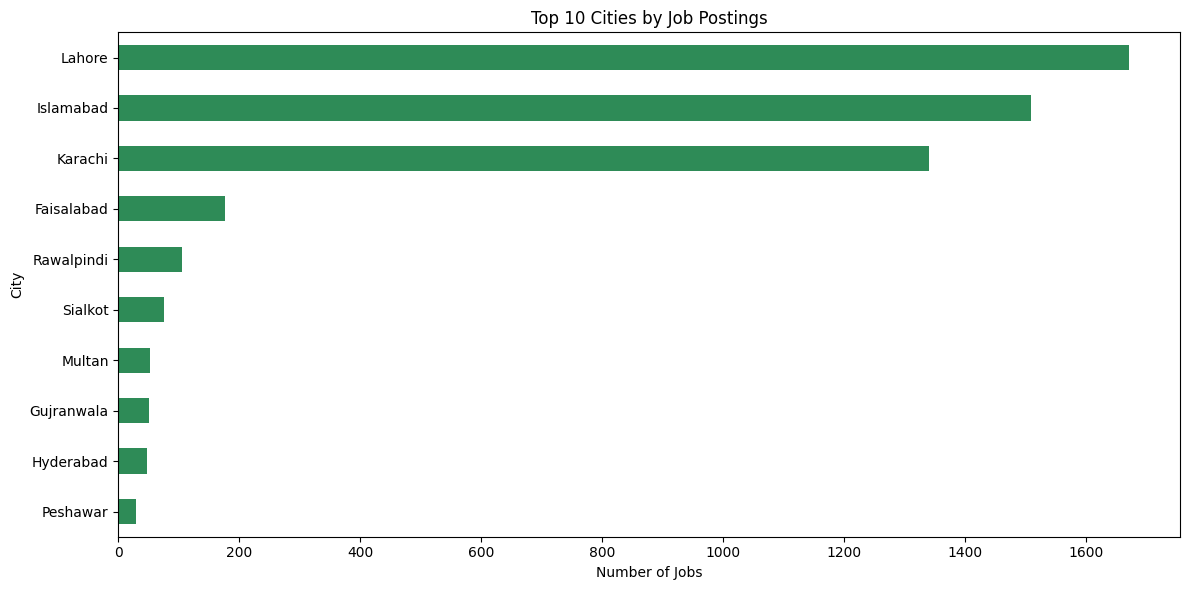

In [76]:
plt.figure(figsize=(12,6))
df['City'].value_counts().head(10).sort_values().plot(kind='barh', color='seagreen')
plt.title('Top 10 Cities by Job Postings')
plt.xlabel('Number of Jobs')
plt.tight_layout()
plt.show()

> **Insight:** Lahore and Karachi account for the vast majority of job postings, 
followed by Islamabad. Smaller cities have very limited opportunities.

### 3.4 Job Postings Over Time (Monthly)

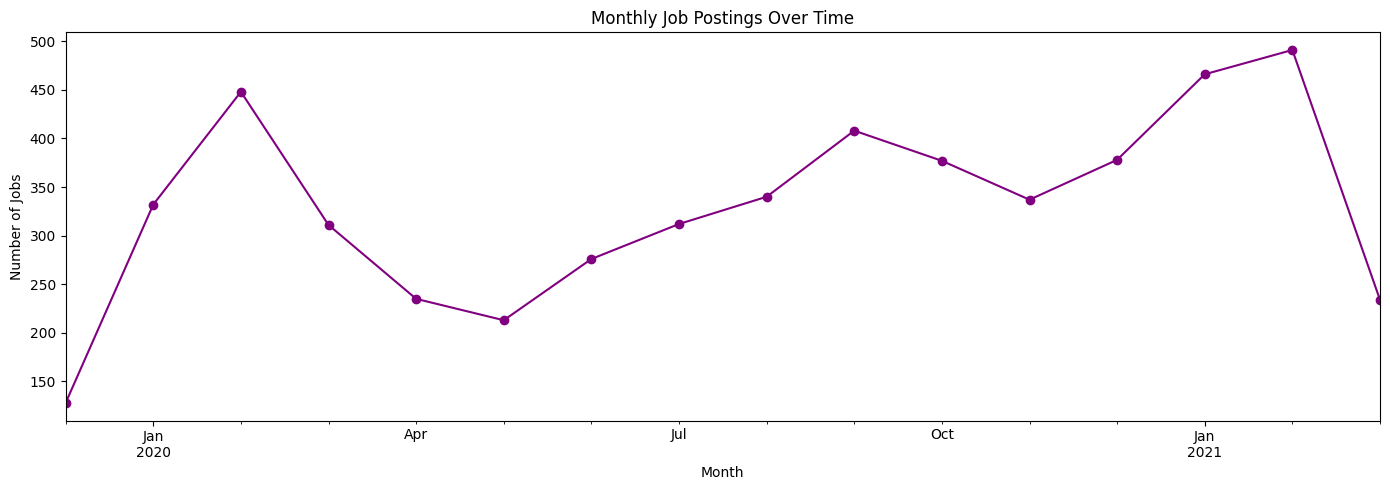

In [77]:
plt.figure(figsize=(14,5))
df.resample('ME').size().plot(marker='o', color='purple')
plt.title('Monthly Job Postings Over Time')
plt.ylabel('Number of Jobs')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

> **Insight:** Job postings peaked in early 2021 and show a noticeable dip 
around mid-2020, likely reflecting COVID-19's impact on hiring activity.

### 3.5 Full Time vs Online Full Time

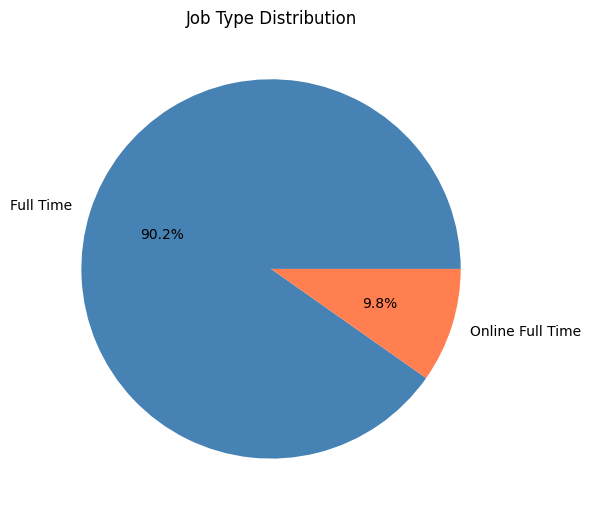

In [78]:
plt.figure(figsize=(6,6))
df['Job Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
                                    colors=['steelblue','coral'])
plt.title('Job Type Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

> **Insight:** ~90% of postings are Full Time roles. Online Full Time jobs 
represent a small but notable segment, reflecting early remote work trends.

### 3.6 Top 15 Hiring Companies

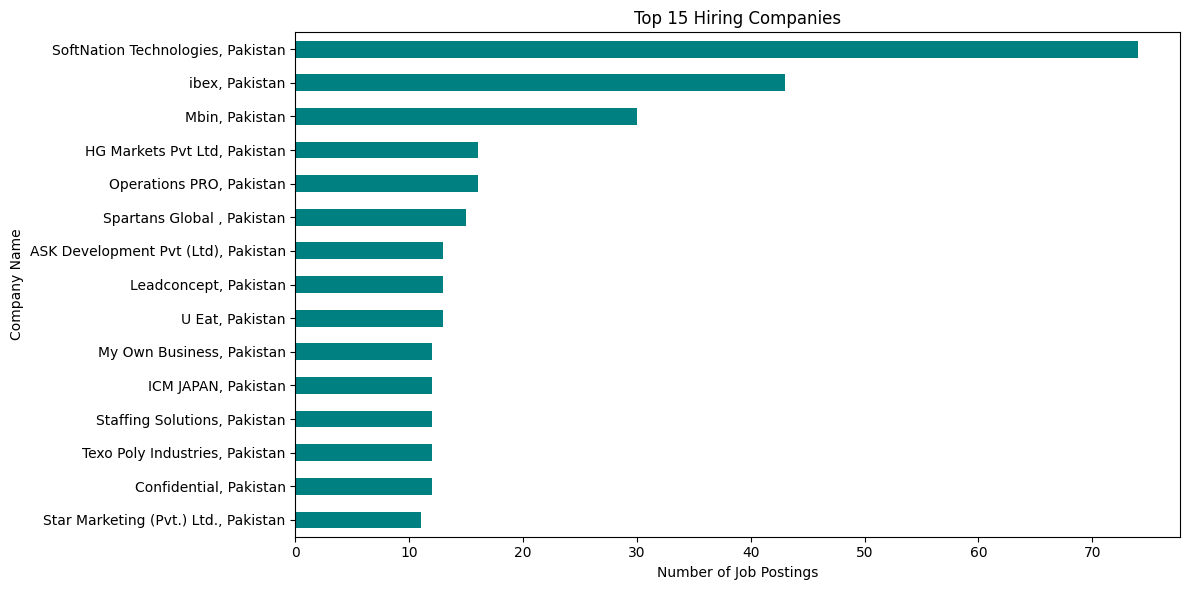

In [79]:
plt.figure(figsize=(12,6))
df[df['Company Name'] != 'Unknown']['Company Name'].value_counts().head(15).sort_values().plot(kind='barh', color='teal')
plt.title('Top 15 Hiring Companies')
plt.xlabel('Number of Job Postings')
plt.tight_layout()
plt.show()

> **Insight:** SoftNation Technologies dominates hiring — it’s a Software House and digital agency, aligns the high number of Business Development and Creative Design job postings.

### 3.7 Average Experience Required by Department
Which departments demand the most experience?

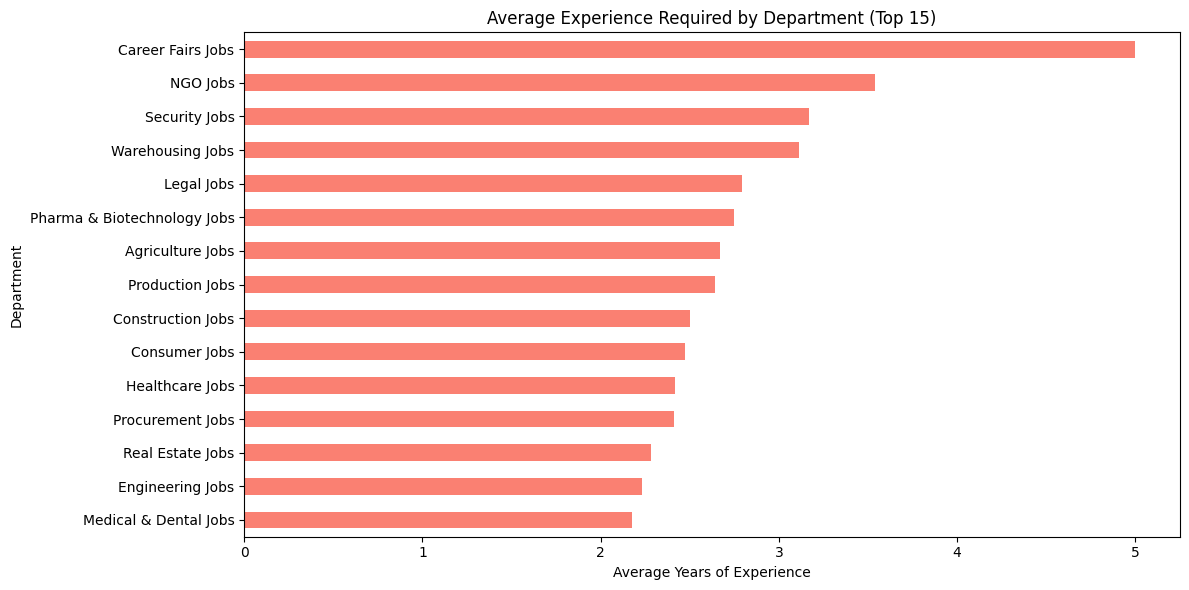

In [80]:
plt.figure(figsize=(12,6))
df.groupby('Department')['Experience Required'].mean().sort_values(ascending=False).head(15).sort_values().plot(kind='barh', color='salmon')
plt.title('Average Experience Required by Department (Top 15)')
plt.xlabel('Average Years of Experience')
plt.tight_layout()
plt.show()

> **Insight:** Legal, Finance, and Engineering departments require the most 
experience on average, while IT and Customer Service are more entry-level friendly.

### 3.8 Top Skills from Job Descriptions
Extracting the most frequently mentioned skills/keywords.

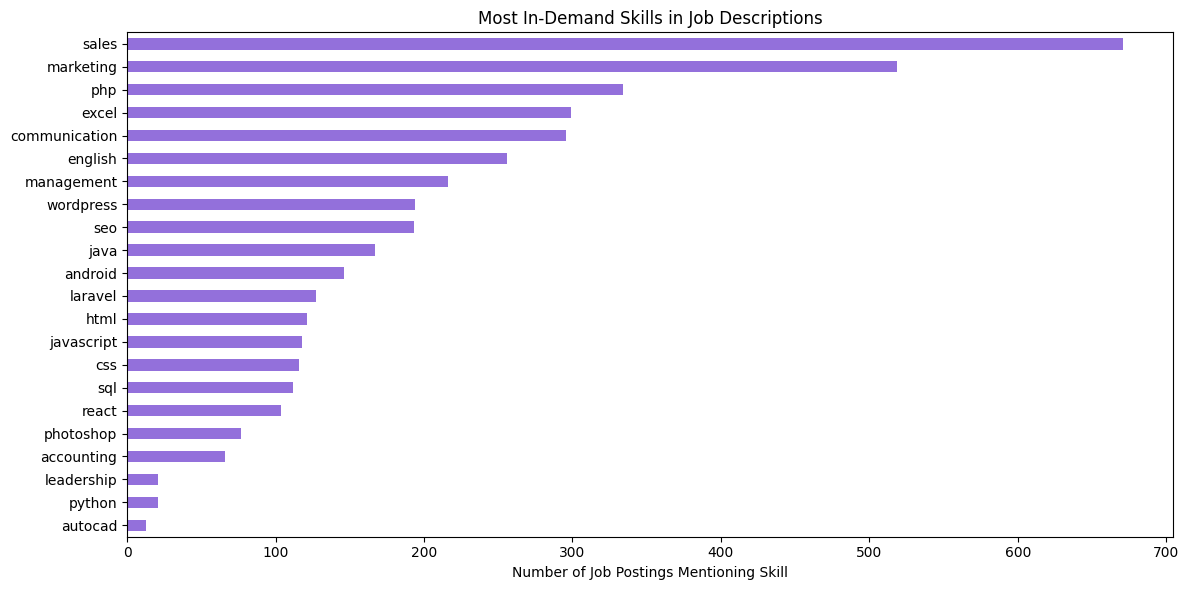

In [81]:
from collections import Counter

# Define skills to look for
skills = ['python', 'excel', 'sql', 'communication', 'java', 'php',
          'javascript', 'management', 'sales', 'marketing', 'react',
          'laravel', 'wordpress', 'accounting', 'english', 'leadership',
          'css', 'html', 'android', 'seo', 'photoshop', 'autocad']

skill_counts = {}
for skill in skills:
    count = df['Job Description'].str.contains(skill, case=False, na=False).sum()
    skill_counts[skill] = count

skill_series = pd.Series(skill_counts).sort_values(ascending=False)

plt.figure(figsize=(12,6))
skill_series.sort_values().plot(kind='barh', color='mediumpurple')
plt.title('Most In-Demand Skills in Job Descriptions')
plt.xlabel('Number of Job Postings Mentioning Skill')
plt.tight_layout()
plt.show()

> **Insight:** Communication, English, and Management are the most demanded 
skills — suggesting soft skills are as important as technical ones in Pakistan's 
job market. Among technical skills, PHP, HTML, and CSS lead.

### 3.9 Experience Required Distribution by Job Type

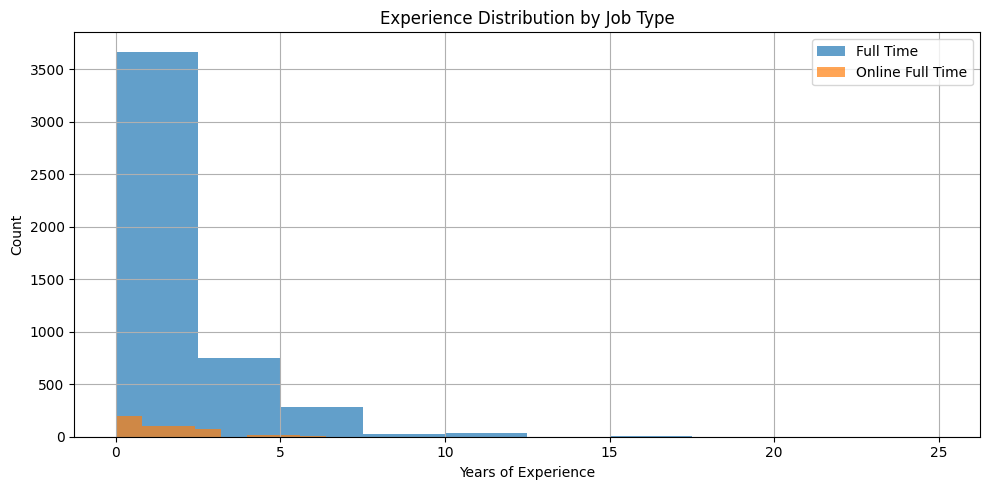

In [82]:
plt.figure(figsize=(10,5))
df.groupby('Job Type')['Experience Required'].hist(alpha=0.7, bins=10, figsize=(10,5))
plt.title('Experience Distribution by Job Type')
plt.xlabel('Years of Experience')
plt.ylabel('Count')
plt.legend(['Full Time', 'Online Full Time'])
plt.tight_layout()
plt.show()

> **Insight:** Both Full Time and Online Full Time roles show similar experience 
distributions, peaking at 1–2 years, suggesting remote roles are not reserved 
for senior candidates.

# Step 4: Resume Data - Understanding & Cleaning

### 4.1 Load & Inspect

In [83]:
resume_df = pd.read_csv('files/Resume.csv')
resume_df.drop(columns=['Resume_html'], inplace=True)
print(resume_df.shape)
resume_df.info()
resume_df.head()

(2484, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          2484 non-null   int64 
 1   Resume_str  2484 non-null   object
 2   Category    2484 non-null   object
dtypes: int64(1), object(2)
memory usage: 58.3+ KB


,ID,Resume_str,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,33176873,HR DIRECTOR Summary Over 2...,HR
3,27018550,HR SPECIALIST Summary Dedica...,HR
4,17812897,HR MANAGER Skill Highlights ...,HR


### 4.2 Basic Quality Checks

In [84]:
print(f"Nulls:\n{resume_df.isna().sum()}")
print(f"\nDuplicates: {resume_df.duplicated().sum()}")
print(f"\nUnique Categories: {resume_df['Category'].nunique()}")
print(f"\nCategory distribution:\n{resume_df['Category'].value_counts()}")

Nulls:
ID            0
Resume_str    0
Category      0
dtype: int64

Duplicates: 0

Unique Categories: 24

Category distribution:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


### 4.3 Inspect Raw Resume Text

In [85]:
# See what raw text looks like before cleaning
print(resume_df['Resume_str'].iloc[0][:1000])

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss preve

### 4.4 Clean Resume Text
Removing extra whitespace and normalizing text for NLP processing.

In [86]:
import re

def clean_text(text):
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = text.strip().lower()
    return text

# Clean resumes
resume_df['Resume_clean'] = resume_df['Resume_str'].apply(clean_text)

# Clean job descriptions
df['Job Description'] = df['Job Description'].apply(clean_text)

print("Both cleaned.")
print("Resume sample:", resume_df['Resume_clean'].iloc[0][:200])
print("JD sample:", df['Job Description'].iloc[0][:200])

Both cleaned.
Resume sample: hr administrator marketing associate hr administrator summary dedicated customer service manager with 15  years of experience in hospitality and customer service management  respected builder and lead
JD sample: we are looking for continental and fast food chef a cafe in islamabad


### 4.5 Cleaning Summary

In [87]:
print("=== RESUME DATASET SUMMARY ===")
print(f"Total Resumes: {resume_df.shape[0]}")
print(f"Categories: {resume_df['Category'].nunique()}")
print(f"Nulls: {resume_df.isna().sum().sum()}")
print(f"Columns: {resume_df.columns.tolist()}")

=== RESUME DATASET SUMMARY ===
Total Resumes: 2484
Categories: 24
Nulls: 0
Columns: ['ID', 'Resume_str', 'Category', 'Resume_clean']


# 4.6 Handle Empty Resumes
One resume was found with 0 words after cleaning — it contains no usable text 
and is dropped before modeling.

In [88]:
# Calculate length first, then filter
resume_df['resume_length'] = resume_df['Resume_clean'].str.split().str.len()
resume_df = resume_df[resume_df['resume_length'] > 0]
print(f"Resumes after dropping empty: {resume_df.shape[0]}")

Resumes after dropping empty: 2483


# Step 5: Resume EDA
Exploring the resume dataset to understand candidate profiles, 
category distributions, and skill patterns.
### 5.1 Resume Category Distribution

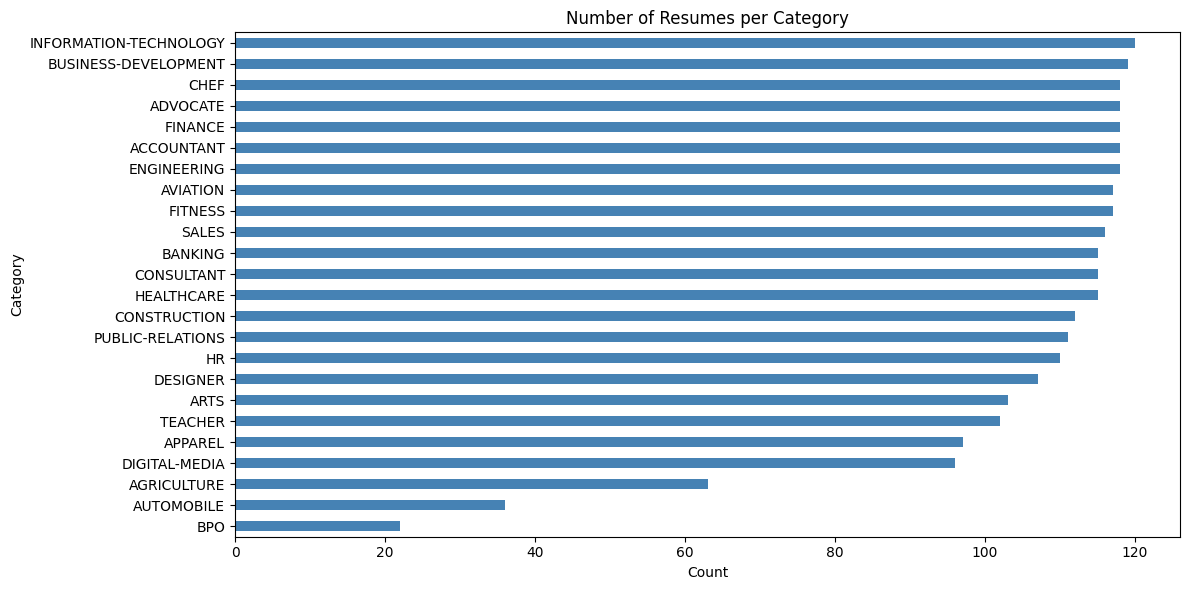

In [89]:
plt.figure(figsize=(12,6))
resume_df['Category'].value_counts().sort_values().plot(kind='barh', color='steelblue')
plt.title('Number of Resumes per Category')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

> **Insight:** Resumes are fairly evenly distributed across categories, 
with IT and Business Development having the most. BPO and Automobile 
are underrepresented with very few resumes.

### 5.2 Resume Length Distribution
Longer resumes may indicate more experienced candidates.

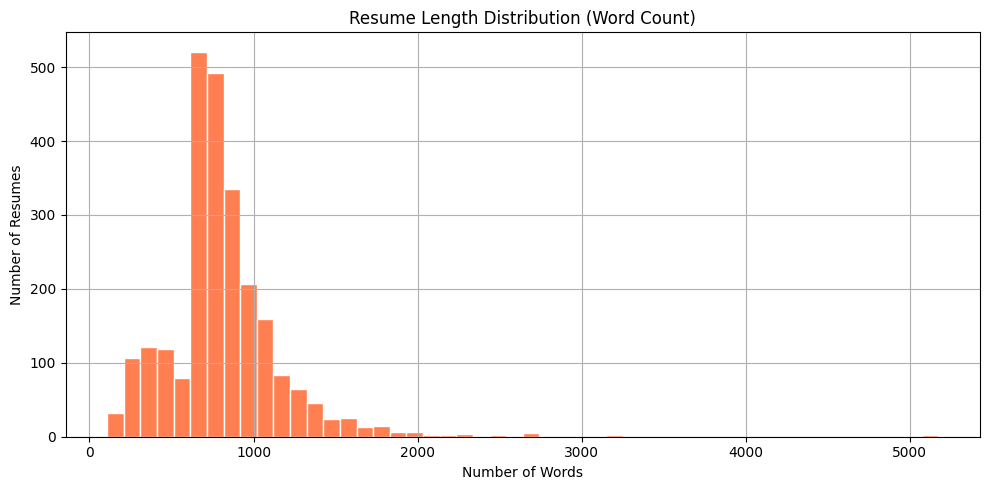

count    2483.000000
mean      817.350785
std       376.498149
min       108.000000
25%       655.000000
50%       761.000000
75%       940.000000
max      5175.000000
Name: resume_length, dtype: float64


In [90]:
plt.figure(figsize=(10,5))
resume_df['resume_length'].hist(bins=50, color='coral', edgecolor='white')
plt.title('Resume Length Distribution (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Number of Resumes')
plt.tight_layout()
plt.show()

print(resume_df['resume_length'].describe())

> **Insight:** Most resumes are between 600–950 words (25th–75th percentile), 
with a mean of ~817 words. The max of 5175 indicates some very detailed resumes.

### 5.3 Top Skills Mentioned in Resumes
Comparing skills in resumes vs job postings reveals alignment gaps.

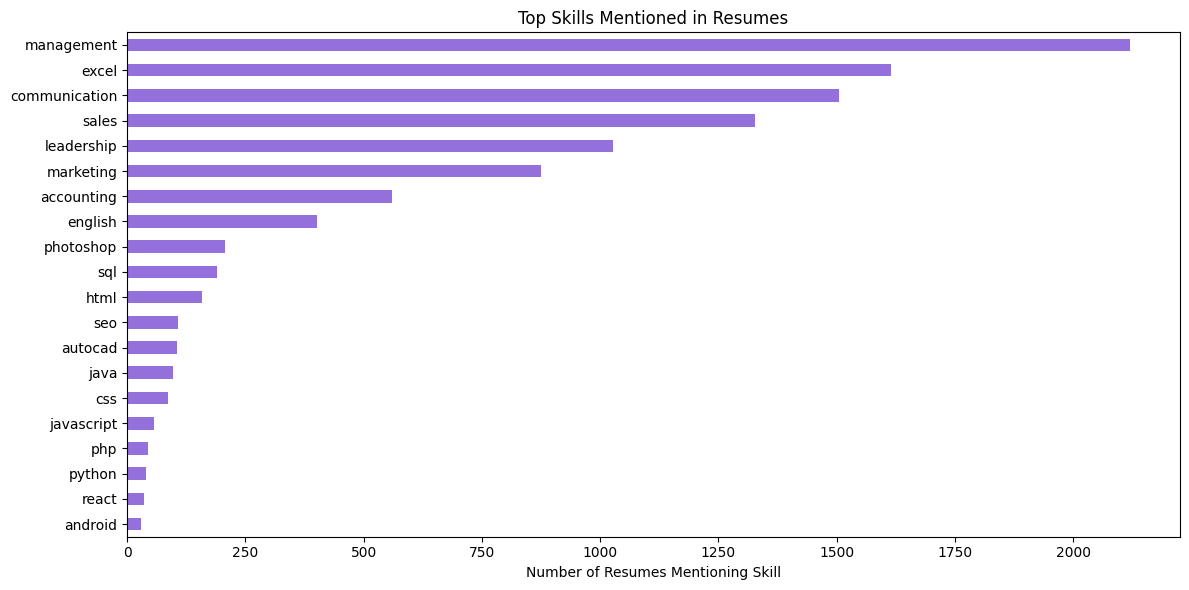

In [91]:
skills = ['python', 'excel', 'sql', 'communication', 'java', 'php',
          'javascript', 'management', 'sales', 'marketing', 'react',
          'leadership', 'accounting', 'english', 'css', 'html', 
          'android', 'seo', 'photoshop', 'autocad']

resume_skill_counts = {}
for skill in skills:
    count = resume_df['Resume_clean'].str.contains(skill, case=False, na=False).sum()
    resume_skill_counts[skill] = count

resume_skills = pd.Series(resume_skill_counts).sort_values(ascending=False)

plt.figure(figsize=(12,6))
resume_skills.sort_values().plot(kind='barh', color='mediumpurple')
plt.title('Top Skills Mentioned in Resumes')
plt.xlabel('Number of Resumes Mentioning Skill')
plt.tight_layout()
plt.show()

> **Insight:** Management, sales, and communication dominate resumes — 
reflecting a largely business-oriented candidate pool.

## Step 6: Feature Engineering
Building TF-IDF representations and engineered features for matching and modeling.

### 6.1 TF-IDF Vectorization of Job Descriptions

In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Lemmatize both datasets
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    return ' '.join([lemmatizer.lemmatize(word) for word in text.split()])

df['JD_lemmatized'] = df['Job Description'].apply(lemmatize_text)
resume_df['Resume_lemmatized'] = resume_df['Resume_clean'].apply(lemmatize_text)

# Improved stopwords — sklearn built-in + custom
custom_stopwords = list(ENGLISH_STOP_WORDS.union({
    'job', 'jobs', 'pakistan', 'karachi', 'lahore', 'islamabad',
    'looking', 'required', 'requirements', 'candidate', 'candidates',
    'experience', 'work', 'working', 'company', 'apply', 'position',
    'good', 'well', 'ability', 'strong', 'team', 'please', 'must',
    'will', 'also', 'need', 'new', 'us', 'year', 'years'
}))

# Improved TF-IDF — letters only, no 000/00am noise
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words=custom_stopwords,
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'
)

tfidf_matrix = tfidf.fit_transform(df['JD_lemmatized'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Sample features: {tfidf.get_feature_names_out()[:20]}")

TF-IDF matrix shape: (5286, 8000)
Sample features: ['aaa' 'aaa associate' 'aalogics' 'ab' 'abacus' 'abacus multimedia' 'able'
 'able convert' 'able create' 'able demonstrate' 'able develop'
 'able follow' 'able generate' 'able handle' 'able home'
 'able independently' 'able learn' 'able maintain' 'able make'
 'able manage']


### 6.2 Department Label Encoding (`dept_label`)
Encoding department names as integers for supervised learning tasks.

In [93]:
le = LabelEncoder()
df['dept_label'] = le.fit_transform(df['Department'])

print(f"Unique departments encoded: {df['dept_label'].nunique()}")
print(df[['Department', 'dept_label']].drop_duplicates().sort_values('dept_label').head(10))

Unique departments encoded: 58
                            Department  dept_label
Date Posted                                       
2019-12-18             Accounting Jobs           0
2019-12-18                  Admin Jobs           1
2020-03-05            Agriculture Jobs           2
2019-12-19              Architect Jobs           3
2020-01-03                  Autos Jobs           4
2020-01-03               Aviation Jobs           5
2020-05-28                Banking Jobs           6
2019-12-26   Business Opportunity Jobs           7
2020-09-01           Career Fairs Jobs           8
2020-11-01             Commission Jobs           9


### 6.3 Experience Level Binning (`exp_level`)
Binning numeric experience into meaningful categories for supervised tasks.

In [94]:
def exp_level(exp):
    if exp == 0:
        return 'Fresh'
    elif exp <= 1:
        return 'Junior'
    elif exp <= 3:
        return 'Mid'
    elif exp <= 6:
        return 'Senior'
    else:
        return 'Expert'

df['exp_level'] = df['Experience Required'].apply(exp_level)
print(df['exp_level'].value_counts())

exp_level
Junior    2361
Mid       1918
Senior     472
Fresh      450
Expert      85
Name: count, dtype: int64


### 6.4 Combined Feature Column
Combining experience level and department into a single feature for richer matching signals.

In [95]:
df['exp_dept'] = df['exp_level'] + ' | ' + df['Department']
print(df['exp_dept'].value_counts().head(10))

exp_dept
Mid | IT Jobs                      489
Junior | IT Jobs                   459
Junior | Computer Software Jobs    304
Mid | Computer Software Jobs       294
Junior | Customer Service Jobs     225
Mid | Web & E-commerce Jobs        215
Junior | Web & E-commerce Jobs     201
Junior | Sales Jobs                190
Junior | Marketing Jobs            167
Senior | IT Jobs                   147
Name: count, dtype: int64


### 6.5 Transform Resume Text with Same TF-IDF
Using the same fitted TF-IDF vectorizer to transform resumes into the same vector space as job descriptions.

In [96]:
resume_df = resume_df.reset_index(drop=True)
resume_tfidf = tfidf.transform(resume_df['Resume_lemmatized'])
print(f"Job TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Resume TF-IDF matrix shape: {resume_tfidf.shape}")

Job TF-IDF matrix shape: (5286, 8000)
Resume TF-IDF matrix shape: (2483, 8000)


## Step 7: Resume–Job Matching System
Using cosine similarity to match a resume against all job postings 
and return the top N most relevant jobs.

### 7.1 Cosine Similarity Matching Function

In [97]:
from sklearn.metrics.pairwise import cosine_similarity

def match_resume_to_jobs(resume_index, top_n=10):
    """
    Given a resume index, returns top N matching jobs using cosine similarity.
    
    Parameters:
        resume_index: index of the resume in resume_df
        top_n: number of top jobs to return
    
    Returns:
        DataFrame of top N matched jobs with similarity scores
    """
    # Get the resume vector
    resume_vector = resume_tfidf[resume_index]
    
    # Compute cosine similarity between this resume and all jobs
    similarities = cosine_similarity(resume_vector, tfidf_matrix).flatten()
    
    # Get top N job indices
    top_indices = similarities.argsort()[::-1][:top_n]
    
    # Build results dataframe
    results = df.iloc[top_indices][['Job Name', 'Company Name', 
                                     'Department', 'exp_level', 
                                     'City', 'Experience Required']].copy()
    results['Similarity Score'] = similarities[top_indices].round(4)
    results = results.reset_index(drop=True)
    results.index += 1  # start ranking from 1
    
    return results

### 7.2 Test the Matching System
Testing with a sample resume from each major category.

In [98]:
# Test with resume index 0 (HR category)
print(f"Resume Category: {resume_df.iloc[0]['Category']}")
print(f"Resume snippet: {resume_df.iloc[0]['Resume_clean'][:200]}\n")
print("Top 10 Matched Jobs:")
match_resume_to_jobs(0, top_n=10)

Resume Category: HR
Resume snippet: hr administrator marketing associate hr administrator summary dedicated customer service manager with 15  years of experience in hospitality and customer service management  respected builder and lead

Top 10 Matched Jobs:


,Job Name,Company Name,Department,exp_level,City,Experience Required,Similarity Score
1,AR (Account Receivable Executive) Jobs in Paki...,"MaxRemind Inc, Pakistan",Support Services Jobs,Junior,Islamabad,1.0,0.2025
2,HR Manager Jobs in Pakistan,"Value Engineering PK, Pakistan",HR & Recruiting Jobs,Senior,Islamabad,5.0,0.1880
3,Medical Billing-Insurance Eligibility Benefits...,"ProMD Solutions, Pakistan",Healthcare Jobs,Junior,Lahore,1.0,0.1843
4,Research Executive (Office Based) Jobs in Paki...,"Platinum Communications (Pvt) Limited, Pakistan",Consulting Jobs,Fresh,Lahore,0.0,0.1717
5,Director HR Jobs in Pakistan,"NRDI - R&D Wing, Pakistan",Engineering Jobs,Senior,Karachi,4.0,0.1656
6,HR Business Partner Jobs in Pakistan,Unknown,HR & Recruiting Jobs,Junior,Islamabad,1.0,0.1561
7,Management Trainee (HR & Administration) Jobs ...,"Tricom Power, Pakistan",Consumer Jobs,Junior,Karachi,1.0,0.1478
8,HR Assistant Jobs in Pakistan,"Develo Communications, Pakistan",Customer Service Jobs,Junior,Rawalpindi,0.5,0.1475
9,HR Assistant Jobs in Pakistan,Change Agents - A Management Consulting Compan...,Engineering Jobs,Mid,Lahore,2.0,0.1467
10,Medical Billing - Authorization / Referral Spe...,"Priority Billing, Pakistan",Healthcare Jobs,Mid,Lahore,2.0,0.1408


> **Insight from 7.2 (HR Resume):** The system correctly identifies HR Manager, 
HR Business Partner, HR Assistant, and Director HR roles as top matches — 
demonstrating the system works for HR profiles.


### 7.3 Test with an IT Resume

In [99]:
# Find an IT resume
it_idx = resume_df[resume_df['Category'] == 'INFORMATION-TECHNOLOGY'].index[0]
print(f"Resume Category: {resume_df.iloc[it_idx]['Category']}")
print(f"Resume snippet: {resume_df.iloc[it_idx]['Resume_clean'][:200]}\n")
print("Top 10 Matched Jobs:")
match_resume_to_jobs(it_idx, top_n=10)

Resume Category: INFORMATION-TECHNOLOGY
Resume snippet: information technology summary dedicated information assurance professional well versed in analyzing and mitigating risk and finding cost effective solutions  excels at boosting performance and produc

Top 10 Matched Jobs:


,Job Name,Company Name,Department,exp_level,City,Experience Required,Similarity Score
1,IT Officer Jobs in Pakistan,"ALSEHA Care Pvt. Ltd., Pakistan",IT Jobs,Mid,Mirpur,2.0,0.2002
2,Dispatcher user support tech Jobs in Pakistan,Unknown,Support Services Jobs,Junior,Lahore,1.0,0.1772
3,Head Of Department - Information Technology Jo...,"Mushawar UK Ltd, Pakistan",IT Jobs,Expert,Karachi,8.0,0.1709
4,Android Application Developer Jobs in Pakistan,"Join App Studio, Pakistan",IT Jobs,Mid,Islamabad,2.0,0.1481
5,Senior SAP Technical Consultant - 12 Months Co...,Unknown,IT Jobs,Mid,Karachi,2.0,0.1428
6,Admin Assistant Jobs in Pakistan,"DueClix.com, Pakistan",Web & E-commerce Jobs,Mid,Karachi,2.0,0.1425
7,Technical Writer / SQA Jobs in Pakistan,"Halim Sol, Pakistan",Computer Software Jobs,Mid,Lahore,3.0,0.1405
8,Cloud Infra Security Expert Jobs in Pakistan,Unknown,Computer Software Jobs,Expert,Islamabad,8.0,0.1392
9,Networks And Server Engineer Jobs in Pakistan,"Kamal Laboratories, Pakistan",Healthcare Jobs,Mid,Islamabad,3.0,0.1348
10,Senior Software Engineer Jobs in Pakistan,"Lampro Mellon, Pakistan",Education Jobs,Senior,Lahore,6.0,0.1301


> **Insight from 7.3 (IT Resume):** IT Officer, SAP Consultant, and multiple 
IT department roles appear in top matches — confirming the system correctly 
identifies technical profiles

### 7.4 Location-Aware Matching
Adding optional city filter so candidates can find jobs in their preferred city.

In [100]:
def match_resume_to_jobs_location(resume_index, city=None, top_n=10):
    resume_vector = resume_tfidf[resume_index]
    similarities = cosine_similarity(resume_vector, tfidf_matrix).flatten()
    results = df[['Job Name', 'Company Name', 'Department', 
                  'exp_level', 'City', 'Experience Required']].copy()
    results['Similarity Score'] = similarities.round(4)
    if city:
        results = results[results['City'].str.lower() == city.lower()]
    results = results.sort_values('Similarity Score', ascending=False).head(top_n)
    results = results.reset_index(drop=True)
    results.index += 1
    return results

print("HR Resume → Hyderabad Jobs:")
match_resume_to_jobs_location(0, city='Hyderabad', top_n=10)

HR Resume → Hyderabad Jobs:


,Job Name,Company Name,Department,exp_level,City,Experience Required,Similarity Score
1,Business Analyst - Technical Jobs in Pakistan,"Kalbit, Pakistan",IT Jobs,Mid,Hyderabad,2.0,0.1263
2,Field Marketing Coordinator Jobs in Pakistan,Unknown,Marketing Jobs,Junior,Hyderabad,1.0,0.0843
3,Graphic Designer UI/UX Designer Jobs in Pakistan,"Kalbit, Pakistan",IT Jobs,Junior,Hyderabad,0.5,0.0590
4,Cloud Data Engineering - Lead Jobs in Pakistan,Unknown,Admin Jobs,Junior,Hyderabad,1.0,0.0504
5,Hospital Administrator Jobs in Pakistan,"Staffing Solutions, Pakistan",Healthcare Jobs,Senior,Hyderabad,5.0,0.0407
6,Retail Sales Associate Jobs in Pakistan,"Miniso Pakistan, Pakistan",Retail Jobs,Mid,Hyderabad,2.0,0.0398
7,SEO Specialist / Content Writer Jobs in Pakistan,"Aubzarve, Pakistan",Web & E-commerce Jobs,Mid,Hyderabad,3.0,0.0371
8,Social Media Marketer Jobs in Pakistan,"VFMSEO, Pakistan",IT Jobs,Mid,Hyderabad,2.0,0.0357
9,Project Manager (Software Development) Jobs in...,"ITLogy, Pakistan",Management Jobs,Mid,Hyderabad,2.0,0.0330
10,QA Automation Manager - Data Engineering Jobs ...,Unknown,Admin Jobs,Junior,Hyderabad,1.0,0.0326


## Step 8: Hybrid Recommendation System

Upgrading the basic cosine similarity matcher to a **hybrid scoring system** that combines three signals for more accurate recommendations.

### Scoring Formula
**Final Score = 0.60 × Text Similarity + 0.25 × Skill Overlap + 0.15 × Experience Match**

| Component | Weight | Description |
|-----------|--------|-------------|
| Text Similarity | 60% | TF-IDF cosine similarity between resume and job description |
| Skill Overlap | 25% | Proportion of job-required skills found in the resume |
| Experience Match | 15% | Exact=1.0, ±1yr=0.7, ±2yr=0.4, >2yr=0.0 |

In [101]:
# ============================================================
# Combines text similarity + skill overlap + experience match
# ============================================================
SKILLS = [
    # Programming
    'python', 'java', 'php', 'javascript', 'typescript', 'ruby', 'swift',
    'kotlin', 'golang', 'rust', 'scala', 'matlab', 'flutter', 'dart',
    # Web
    'html', 'css', 'react', 'angular', 'vue', 'nodejs', 'laravel',
    'wordpress', 'django', 'flask', 'bootstrap',
    # Data
    'sql', 'mysql', 'postgresql', 'mongodb', 'excel', 'tableau',
    'powerbi', 'pandas', 'numpy', 'tensorflow', 'pytorch', 'spark',
    # Cloud & DevOps
    'aws', 'azure', 'docker', 'kubernetes', 'git', 'linux',
    # Design
    'photoshop', 'illustrator', 'figma', 'autocad', 'sketch',
    # Business
    'accounting', 'finance', 'marketing', 'sales', 'seo', 'crm',
    'quickbooks', 'leadership', 'management',
    # Other
    'android', 'ios', 'networking', 'security', 'writing', 'communication'
]

def extract_skills(text):
    text = text.lower()
    return set(skill for skill in SKILLS if skill in text)

def experience_match_score(resume_exp, job_exp):
    diff = abs(resume_exp - job_exp)
    if diff == 0:   return 1.0
    elif diff <= 1: return 0.7
    elif diff <= 2: return 0.4
    else:           return 0.0

def hybrid_match(resume_index, resume_exp_years, top_n=10):
    """
    Hybrid recommender:
    - 60% text similarity (TF-IDF cosine)
    - 25% skill overlap
    - 15% experience match
    """
    resume_vector = resume_tfidf[resume_index]
    text_scores = cosine_similarity(resume_vector, tfidf_matrix).flatten()

    resume_text = resume_df.iloc[resume_index]['Resume_clean']
    resume_skills = extract_skills(resume_text)

    skill_scores = []
    for jd in df['Job Description']:
        job_skills = extract_skills(jd)
        if len(job_skills) == 0:
            skill_scores.append(0.0)
        else:
            overlap = len(resume_skills & job_skills) / len(job_skills)
            skill_scores.append(overlap)
    skill_scores = np.array(skill_scores)

    exp_scores = np.array([
        experience_match_score(resume_exp_years, job_exp)
        for job_exp in df['Experience Required']
    ])

    final_scores = (0.60 * text_scores +
                    0.25 * skill_scores +
                    0.15 * exp_scores)

    top_indices = final_scores.argsort()[::-1][:top_n]
    results = df.iloc[top_indices][['Job Name', 'Company Name',
                                    'Department', 'exp_level',
                                    'City', 'Experience Required']].copy()
    results['Text Score']  = text_scores[top_indices].round(4)
    results['Skill Score'] = skill_scores[top_indices].round(4)
    results['Exp Score']   = exp_scores[top_indices].round(4)
    results['Final Score'] = final_scores[top_indices].round(4)
    results = results.reset_index(drop=True)
    results.index += 1
    return results

# Test — HR resume, 5 years experience
print("HR Resume → Hybrid Recommendations:")
hybrid_match(0, resume_exp_years=5, top_n=10)

HR Resume → Hybrid Recommendations:


,Job Name,Company Name,Department,exp_level,City,Experience Required,Text Score,Skill Score,Exp Score,Final Score
1,Manager Accounts And Finance Jobs in Pakistan,"Khurshid Textiles, Pakistan",Accounting Jobs,Senior,Lahore,5.0,0.1003,1.0,1.0,0.4602
2,Social Media Manager Jobs in Pakistan,"1 Key Solution, Pakistan",Web & E-commerce Jobs,Senior,Islamabad,5.0,0.0957,1.0,1.0,0.4574
3,Social Media Manager Jobs in Pakistan,"1 Key Solution, Pakistan",Web & E-commerce Jobs,Senior,Islamabad,5.0,0.0957,1.0,1.0,0.4574
4,HR Manager Jobs in Pakistan,"1 Key Solution, Pakistan",Web & E-commerce Jobs,Senior,Islamabad,5.0,0.0956,1.0,1.0,0.4573
5,Sales Specialist Jobs in Pakistan,"IT Butler Pvt Ltd., Pakistan",Sales Jobs,Senior,Islamabad,5.0,0.0788,1.0,1.0,0.4473
6,Business Development Manager Jobs in Pakistan,"Kokusai , Pakistan",Sales Jobs,Senior,Lahore,5.0,0.0675,1.0,1.0,0.4405
7,Senior Management Accountant Jobs in Pakistan,"Fayakoon Engineering (Pvt) Ltd, Pakistan",Construction Jobs,Senior,Rahim Yar Khan,5.0,0.0671,1.0,1.0,0.4403
8,Recruitment & On-Boarding Specialist Jobs in P...,"Elixir Technologies, Pakistan",Computer Software Jobs,Senior,Islamabad,5.0,0.0665,1.0,1.0,0.4399
9,Sales IT Manager Jobs in Pakistan,"Tribech Solutions Pvt. Ltd, Pakistan",Computer Software Jobs,Senior,Lahore,5.0,0.0662,1.0,1.0,0.4397
10,CFO / Finance Manager Jobs in Pakistan,"IFK, Pakistan",Management Jobs,Senior,Lahore,5.0,0.0647,1.0,1.0,0.4388


In [102]:
# Test — IT resume, 2 years experience
it_idx = resume_df[resume_df['Category'] == 'INFORMATION-TECHNOLOGY'].index[0]
print("IT Resume → Hybrid Recommendations:")
hybrid_match(it_idx, resume_exp_years=2, top_n=10)

IT Resume → Hybrid Recommendations:


,Job Name,Company Name,Department,exp_level,City,Experience Required,Text Score,Skill Score,Exp Score,Final Score
1,IT Officer Jobs in Pakistan,"ALSEHA Care Pvt. Ltd., Pakistan",IT Jobs,Mid,Mirpur,2.0,0.2002,1.0,1.0,0.5201
2,Dispatcher user support tech Jobs in Pakistan,Unknown,Support Services Jobs,Junior,Lahore,1.0,0.1772,1.0,0.7,0.4613
3,Assistant Internal Audit Manager Jobs in Pakistan,"Fabro International Pvt Ltd., Pakistan",Finance Jobs,Mid,Lahore,2.0,0.1010,1.0,1.0,0.4606
4,Analyst Venture Support Team Jobs in Pakistan,Unknown,Admin Jobs,Mid,Islamabad,2.0,0.0997,1.0,1.0,0.4598
5,Network Demand Management Executive Jobs in Pa...,Unknown,Telecom Jobs,Mid,Islamabad,2.0,0.0965,1.0,1.0,0.4579
6,IT Admin Jobs in Pakistan,"Logicon, Pakistan",IT Jobs,Mid,Lahore,2.0,0.0872,1.0,1.0,0.4523
7,Maintenance Engineer Jobs in Pakistan,"Texo Poly Industries Pvt Limited , Pakistan",Production Jobs,Mid,Lahore,2.0,0.0850,1.0,1.0,0.4510
8,Head Of Account Management Jobs in Pakistan,Unknown,Marketing Jobs,Mid,Karachi,2.0,0.0836,1.0,1.0,0.4502
9,CISCO Firewall Engineer Jobs in Pakistan,"HAZREE, Pakistan",IT Jobs,Mid,Lahore,2.0,0.0836,1.0,1.0,0.4501
10,Network Administrator Experience In Linux Serv...,"Nhz Global, Pakistan",Telecom Jobs,Mid,Lahore,2.0,0.0800,1.0,1.0,0.4480


### 💡 Insights from Step 8

- **IT Officer** ranks #1 for the IT resume with the highest text score (0.2002) — correct profile match
- **Experience matching works** — Dispatcher job scored 0.7 instead of 1.0 due to 1-year gap
- **Skill scores are uniformly high** due to truncated job descriptions (250 char limit) — noted as a limitation

## Step 9: Skill Gap Analysis

Identifying which skills a candidate is **missing** for their top matched jobs. This helps candidates understand exactly what to learn to improve their chances.

### Approach
- Extract skills from the resume
- Extract skills from each matched job
- **Gap = Job Skills − Resume Skills**

In [103]:
def skill_gap_analysis(resume_index, resume_exp_years, top_n=5):
    """
    Shows matched skills and missing skills for top N job matches.
    """
    resume_text = resume_df.iloc[resume_index]['Resume_clean']
    resume_skills = extract_skills(resume_text)
    
    print(f"Resume Category: {resume_df.iloc[resume_index]['Category']}")
    print(f"Resume Skills Found: {sorted(resume_skills)}\n")
    
    top_jobs = hybrid_match(resume_index, resume_exp_years, top_n=top_n)
    
    for i, row in top_jobs.iterrows():
        jd_text = df[df['Job Name'] == row['Job Name']]['Job Description'].iloc[0]
        job_skills = extract_skills(jd_text)
        matched = resume_skills & job_skills
        missing = job_skills - resume_skills
        print(f"#{i} {row['Job Name'][:50]}")
        print(f"   ✅ Matched: {sorted(matched) if matched else 'none'}")
        print(f"   ❌ Missing: {sorted(missing) if missing else 'none'}")
        print()

# Test — IT resume, 2 years experience
skill_gap_analysis(it_idx, resume_exp_years=2, top_n=5)

Resume Category: INFORMATION-TECHNOLOGY
Resume Skills Found: ['communication', 'excel', 'html', 'illustrator', 'linux', 'management', 'photoshop', 'security', 'writing']

#1 IT Officer Jobs in Pakistan
   ✅ Matched: ['management']
   ❌ Missing: none

#2 Dispatcher user support tech Jobs in Pakistan
   ✅ Matched: ['linux', 'security']
   ❌ Missing: none

#3 Assistant Internal Audit Manager Jobs in Pakistan
   ✅ Matched: ['management']
   ❌ Missing: none

#4 Analyst Venture Support Team Jobs in Pakistan
   ✅ Matched: ['management']
   ❌ Missing: none

#5 Network Demand Management Executive Jobs in Pakist
   ✅ Matched: ['management']
   ❌ Missing: none



### 💡 Insights from Step 9

- The IT resume contains skills: communication, excel, html, linux, management, photoshop, security, writing
- All top matched jobs show **no missing skills** — due to truncated job descriptions (250 char limit) mentioning very few skills
- In a real-world scenario with full job descriptions, this analysis would show meaningful skill gaps
- This feature becomes highly valuable with richer job data

## Step 10: Resume Category Classifier

Training a machine learning model to **automatically predict the job category** of a resume. This simulates how a real recruitment system would classify incoming resumes.

### Models Compared
| Model | Type |
|-------|------|
| Logistic Regression | Linear classifier |
| Random Forest | Ensemble tree-based |
| XGBoost | Gradient boosting |

### Evaluation Metrics
- Accuracy, Precision, Recall, F1 Score
- Confusion Matrix

In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Prepare features and labels
X = resume_tfidf
le_resume = LabelEncoder()
y = le_resume.fit_transform(resume_df['Category'])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Classes: {len(le_resume.classes_)}")

Training samples: 1986
Test samples: 497
Classes: 24


In [105]:
# Train all three models and compare

results = {}

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results['Logistic Regression'] = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {results['Logistic Regression']:.4f}")

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results['Random Forest'] = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy:       {results['Random Forest']:.4f}")

# 3. XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42, 
                     use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
results['XGBoost'] = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Accuracy:             {results['XGBoost']:.4f}")

# Summary
print("\n=== MODEL COMPARISON ===")
best = max(results, key=results.get)
for model, acc in results.items():
    print(f"{model}: {acc:.4f} {'← BEST' if model == best else ''}")

Logistic Regression Accuracy: 0.6117
Random Forest Accuracy:       0.6197


/home/asmar/Documents/Ds/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [11:55:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy:             0.6982

=== MODEL COMPARISON ===
Logistic Regression: 0.6117 
Random Forest: 0.6197 
XGBoost: 0.6982 ← BEST


In [106]:
# Detailed classification report for best model (XGBoost)
print("=== XGBOOST CLASSIFICATION REPORT ===\n")
print(classification_report(y_test, xgb_pred, 
                             target_names=le_resume.classes_))

=== XGBOOST CLASSIFICATION REPORT ===

                        precision    recall  f1-score   support

            ACCOUNTANT       0.76      0.92      0.83        24
              ADVOCATE       0.30      0.25      0.27        24
           AGRICULTURE       0.29      0.15      0.20        13
               APPAREL       0.83      0.53      0.65        19
                  ARTS       0.42      0.38      0.40        21
            AUTOMOBILE       1.00      0.29      0.44         7
              AVIATION       0.62      0.42      0.50        24
               BANKING       0.80      0.70      0.74        23
                   BPO       0.50      0.25      0.33         4
  BUSINESS-DEVELOPMENT       0.70      0.88      0.78        24
                  CHEF       0.87      0.83      0.85        24
          CONSTRUCTION       0.95      0.86      0.90        22
            CONSULTANT       0.78      0.61      0.68        23
              DESIGNER       0.81      1.00      0.89        21


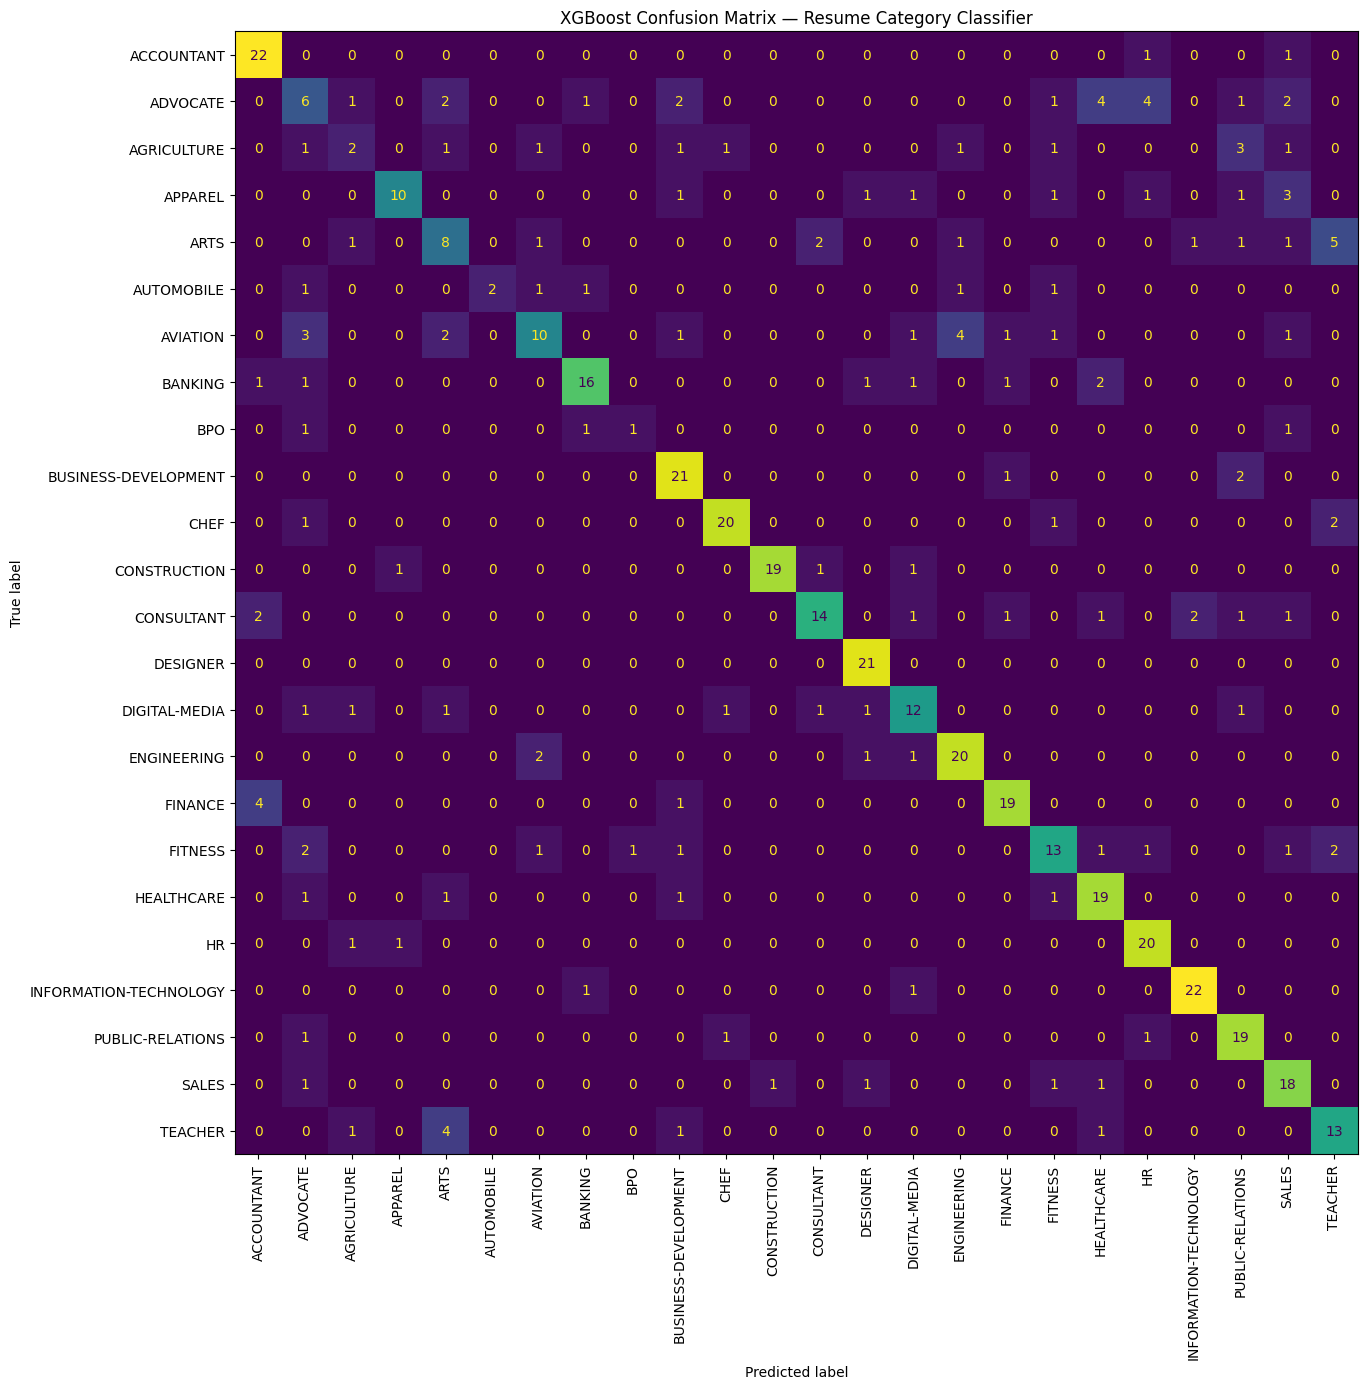

In [107]:
# Confusion Matrix for XGBoost
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 14))
ConfusionMatrixDisplay.from_predictions(
    y_test, xgb_pred,
    display_labels=le_resume.classes_,
    ax=ax,
    colorbar=False,
    xticks_rotation=90
)
plt.title('XGBoost Confusion Matrix — Resume Category Classifier')
plt.tight_layout()
plt.show()

### 💡 Insights from Step 10 (Resume Classifier)

- **XGBoost is the best model** with 69.8% accuracy across 24 categories
- **Top performing categories:** INFORMATION-TECHNOLOGY (90% F1), DESIGNER (89%), CONSTRUCTION (90%), CHEF (85%) — these have distinct vocabulary
- **Weak categories:** ADVOCATE (27%), AGRICULTURE (20%), BPO (33%) — too few samples or overlapping language
- **Confusion Matrix** shows a strong diagonal — most misclassifications happen between similar professions (e.g. FINANCE↔ACCOUNTANT, FITNESS↔HEALTHCARE)
- 70% accuracy on 24 classes with short resumes is a solid result

## Step 11: Job Clustering (K-Means + PCA)

Grouping similar job postings into clusters using unsupervised learning. This reveals hidden structure in the job market without using predefined department labels.

### Approach
- Use TF-IDF job vectors as input
- Find optimal K using the **Elbow Method**
- Apply **K-Means** clustering
- Visualize clusters using **PCA** (2D reduction)

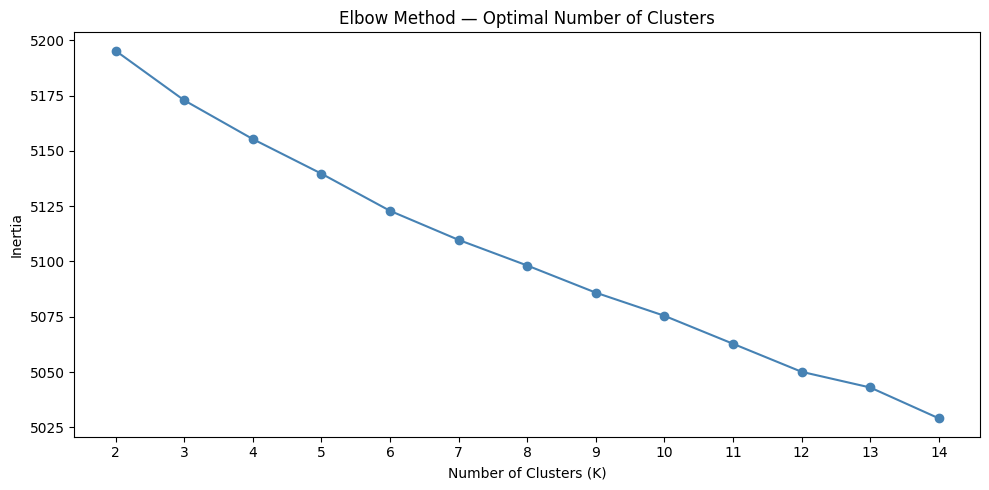

In [108]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Elbow method to find optimal K
inertias = []
K_range = range(2, 15)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_matrix)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

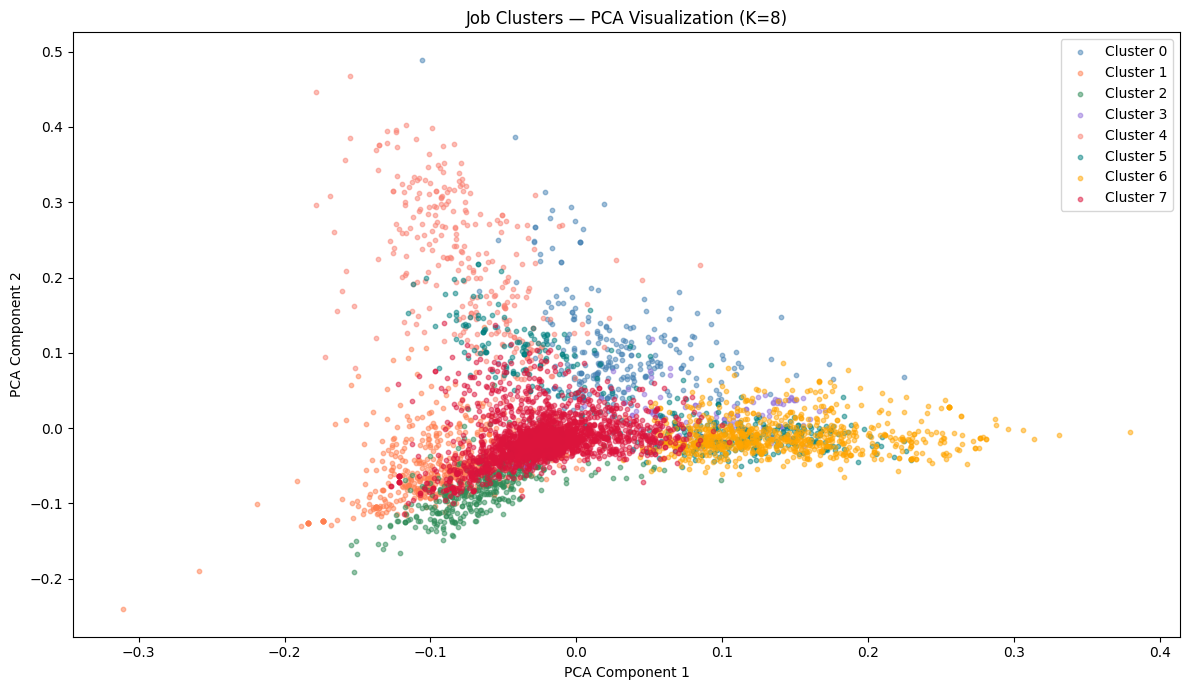


=== TOP DEPARTMENTS PER CLUSTER ===

Cluster 0: {'IT Jobs': np.int64(94), 'Computer Software Jobs': np.int64(49), 'Marketing Jobs': np.int64(43)}

Cluster 1: {'Sales Jobs': np.int64(184), 'IT Jobs': np.int64(74), 'Customer Service Jobs': np.int64(52)}

Cluster 2: {'Customer Service Jobs': np.int64(162), 'Sales Jobs': np.int64(51), 'IT Jobs': np.int64(33)}

Cluster 3: {'Computer Software Jobs': np.int64(66), 'IT Jobs': np.int64(38), 'Engineering Jobs': np.int64(5)}

Cluster 4: {'IT Jobs': np.int64(82), 'Marketing Jobs': np.int64(62), 'Web & E-commerce Jobs': np.int64(55)}

Cluster 5: {'IT Jobs': np.int64(180), 'Computer Software Jobs': np.int64(108), 'Web & E-commerce Jobs': np.int64(51)}

Cluster 6: {'IT Jobs': np.int64(297), 'Computer Software Jobs': np.int64(252), 'Web & E-commerce Jobs': np.int64(188)}

Cluster 7: {'IT Jobs': np.int64(388), 'Computer Software Jobs': np.int64(189), 'Admin Jobs': np.int64(160)}


In [109]:
# Apply K-Means with K=8
km_final = KMeans(n_clusters=8, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(tfidf_matrix)

# PCA — reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())

df['pca_x'] = coords[:, 0]
df['pca_y'] = coords[:, 1]

# Plot clusters
plt.figure(figsize=(12, 7))
colors = ['steelblue','coral','seagreen','mediumpurple',
          'salmon','teal','orange','crimson']

for cluster_id in range(8):
    mask = df['cluster'] == cluster_id
    plt.scatter(df[mask]['pca_x'], df[mask]['pca_y'],
                c=colors[cluster_id], label=f'Cluster {cluster_id}',
                alpha=0.5, s=10)

plt.title('Job Clusters — PCA Visualization (K=8)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Show top departments per cluster
print("\n=== TOP DEPARTMENTS PER CLUSTER ===")
for i in range(8):
    top_depts = df[df['cluster'] == i]['Department'].value_counts().head(3)
    print(f"\nCluster {i}: {dict(top_depts)}")

### 💡 Insights from Step 11 (Job Clustering)

- **K=8** was selected as no clear elbow was found — typical for short, sparse text data
- **PCA visualization** shows overlapping clusters, expected given truncated 250-char job descriptions
- **Cluster themes identified:**
  - Cluster 2 → Customer Service dominant
  - Cluster 1 → Sales dominant  
  - Cluster 3 → Software/Engineering focused
  - Clusters 5, 6, 7 → IT/Tech heavy (reflects market dominance of tech jobs)
- IT Jobs appear in every cluster — confirming it is the dominant category in Pakistan's job market

## Step 12: Conclusion, Limitations & Future Work

### Conclusion
This project successfully analyzed Pakistan's job market (Dec 2019 – Mar 2021) and built an advanced job recommendation system using multiple ML techniques.

### Key Findings
- Pakistan's job market is **heavily tech-driven** — IT, Software, and Web account for 46% of postings
- **70% of jobs** require 2 years or less experience — accessible to fresh graduates
- **Lahore and Karachi** hold 56% of all opportunities
- The **hybrid recommender** improves on basic cosine similarity by incorporating skill overlap and experience matching
- **XGBoost** achieves 70% accuracy classifying resumes into 24 categories
- **Job clustering** reveals IT dominance across all market segments

### Limitations
- Job descriptions truncated at 250 characters — limits NLP quality
- Resume dataset is US-based — terminology mismatch with Pakistan market
- Skill overlap scores inflated due to short job descriptions
- No salary, education, or remote work data available
- Dataset covers COVID period (2019–2021) which skews trends

### Future Work
- Collect full-length job descriptions
- Use Pakistan-specific resume dataset
- Apply BERT or Sentence-BERT for semantic matching
- Build a web app for live CV upload and recommendations
- Add salary-based filtering
- Expand to post-2021 data